## Section 0 — Environment Check


In [ ]:
# Section 0: Environment check
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import sys
import platform

print(f"Python:        {sys.version.split()[0]}")
print(f"PyTorch:       {torch.__version__}")
print(f"Torchvision:   {torchvision.__version__}")

# Device selection: CUDA > MPS (Apple Silicon) > CPU
if torch.cuda.is_available():
    device = "cuda"
    print(f"GPU:           {torch.cuda.get_device_name(0)}")
    print(f"CUDA version:  {torch.version.cuda}")
elif torch.backends.mps.is_available():
    device = "mps"
    print(f"Device:        Apple MPS (Metal)")
else:
    device = "cpu"
    print(f"Device:        CPU (training will be slow)")

print(f"Selected device: {device}")

Python:        3.13.9
PyTorch:       2.11.0
Torchvision:   0.26.0
Device:        Apple MPS (Metal)
Selected device: mps


## Section 1 — Paths & `RESULTS/` folder


```
RESULTS/
├── splits/              # JSON of which image goes to labeled/unlabeled/val
├── simclr/              # SimCLR checkpoint + loss curve (trained once)
├── 1pct/                # one folder per label percentage
│   ├── B1_supervised/   #   metrics.json, classification_report.txt,
│   ├── B3_self_supervised/      confusion_matrix.png, training_curves.png,
│   ├── B4_semi_supervised/      per_class_metrics.png, checkpoint.pth
│   └── B5_hybrid/
├── 20pct/
├── 40pct/
└── summary/             # cross-method comparison at the end
```

In [ ]:
import os



TOMATO_PATH = "/Users/sherry/Desktop/Tomato_Disease/DATASET"
PROJECT_DIR = "/Users/sherry/Desktop/Tomato_Disease"


# Top-level RESULTS tree
RESULTS_DIR = f"{PROJECT_DIR}/RESULTS"
os.makedirs(f"{RESULTS_DIR}/splits", exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/simclr", exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/summary", exist_ok=True)
for pct in ["1pct", "20pct", "40pct"]:
    for method in ["B1_supervised", "B3_self_supervised",
                   "B4_semi_supervised", "B5_hybrid"]:
        os.makedirs(f"{RESULTS_DIR}/{pct}/{method}", exist_ok=True)
print(f"RESULTS tree ready under: {RESULTS_DIR}")

# Sanity check the dataset folder
assert os.path.isdir(TOMATO_PATH), f"Dataset not found at {TOMATO_PATH}"
tomato_classes = sorted([d for d in os.listdir(TOMATO_PATH)
                         if os.path.isdir(os.path.join(TOMATO_PATH, d))])
print(f"\nFound {len(tomato_classes)} class folder(s):")
total = 0
for c in tomato_classes:
    n = len(os.listdir(os.path.join(TOMATO_PATH, c)))
    total += n
    print(f"  {c:<50} {n:>5}")
print(f"  {'TOTAL':<50} {total:>5}")

RESULTS tree ready under: /Users/sherry/Desktop/Tomato_Disease/RESULTS

Found 10 class folder(s):
  Tomato_Bacterial_spot                               2127
  Tomato_Early_blight                                 1000
  Tomato_Late_blight                                  1909
  Tomato_Leaf_Mold                                     952
  Tomato_Septoria_leaf_spot                           1771
  Tomato_Spider_mites_Two_spotted_spider_mite         1676
  Tomato__Target_Spot                                 1404
  Tomato__Tomato_YellowLeaf__Curl_Virus               3208
  Tomato__Tomato_mosaic_virus                          373
  Tomato_healthy                                      1591
  TOTAL                                              16011


## Section 2 — Hyperparameters

All hyperparameters live here so they're easy to audit. Names match the original notebook
(`LABEL_PCT`, `VAL_PCT`, `BATCH_SIZE`, `SIMCLR_EPOCHS`, `LR_SIMCLR`, `SIMCLR_TEMP`,
`LR_FINETUNE`, `K_AUGMENTS`, `SHARPEN_TEMP`, `MIXUP_ALPHA`, `LAMBDA_U`). `LABEL_PCT`
is set later in Section 9 — it's the only knob you change between experiments.

In [3]:
import torch

# === SPLIT RATIOS ===
# LABEL_PCT is set per-experiment in Section 9. VAL_PCT stays fixed at 10%
# across all three experiments. Unlabeled = whatever is left over.
VAL_PCT     = 0.10
# (LABEL_PCT defined in Section 9)

# === TRAINING ===
IMG_SIZE       = 224
BATCH_SIZE     = 128
NUM_WORKERS    = 0    # 0 is safest on macOS/MPS; bump to 4 only on Linux+CUDA

# SimCLR
SIMCLR_EPOCHS  = 10
LR_SIMCLR      = 1e-4      # fine-tuning from ImageNet (winning config)
SIMCLR_TEMP    = 0.5

# MixMatch
LR_FINETUNE     = 1e-3
K_AUGMENTS      = 2
SHARPEN_TEMP    = 0.5
MIXUP_ALPHA     = 0.75
LAMBDA_U        = 1.0

# Common training duration
EPOCHS_DEFAULT  = 30
SEED            = 42

print(f"Device: {device}")
print(f"VAL_PCT: {VAL_PCT}  BATCH_SIZE: {BATCH_SIZE}  IMG_SIZE: {IMG_SIZE}")

Device: mps
VAL_PCT: 0.1  BATCH_SIZE: 128  IMG_SIZE: 224


## Section 3 — Imports, utilities, base dataset



In [4]:
import random
import numpy as np
import json
import copy
import time
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import ImageFolder
from PIL import Image
from tqdm import tqdm
from collections import Counter


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def empty_cache():
    """Cross-backend cache clear. Replaces torch.cuda.empty_cache()."""
    if device == "cuda":
        torch.cuda.empty_cache()
    elif device == "mps":
        torch.mps.empty_cache()


# Load the base dataset (path-only, no transform — we wrap with transforms later)
base_dataset = ImageFolder(root=TOMATO_PATH)
NUM_CLASSES = len(base_dataset.classes)
print(f"Classes ({NUM_CLASSES}):")
for i, c in enumerate(base_dataset.classes):
    print(f"  {i}: {c}")

Classes (10):
  0: Tomato_Bacterial_spot
  1: Tomato_Early_blight
  2: Tomato_Late_blight
  3: Tomato_Leaf_Mold
  4: Tomato_Septoria_leaf_spot
  5: Tomato_Spider_mites_Two_spotted_spider_mite
  6: Tomato__Target_Spot
  7: Tomato__Tomato_YellowLeaf__Curl_Virus
  8: Tomato__Tomato_mosaic_virus
  9: Tomato_healthy


## Section 4 — Transforms & dataset wrappers

Three transforms:
- `eval_transform` — deterministic resize + normalize (used for val and anchor loaders)
- `train_transform` — flip + random crop + normalize (used by B1 / B3 / labeled side of B4 / B5)
- `simclr_transform` — heavy SimCLR augmentation (used only during SimCLR pretraining)

Three dataset wrappers:
- `LabeledSubset` — index list + transform → returns `(img, label)`
- `UnlabeledKAug` — returns **K** augmented views of each image (for MixMatch's pseudo-label averaging)
- `SimCLRDataset` — returns **2** independently augmented views (for the contrastive loss)

Plus `sharpen` and `mixup` helpers used by MixMatch.

In [5]:
# ---- Transforms ----
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(IMG_SIZE, padding=16),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
weak_transform = train_transform  # alias used by MixMatch methods

simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


# ---- Dataset wrappers ----
class LabeledSubset(Dataset):
    """Subset wrapper that applies a transform to raw images."""
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        path, label = self.base.samples[self.indices[i]]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label


class UnlabeledKAug(Dataset):
    """Returns K augmented views of each unlabeled image (for MixMatch)."""
    def __init__(self, base_dataset, indices, transform, K=2):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform
        self.K = K

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        path, _ = self.base.samples[self.indices[i]]
        img = Image.open(path).convert("RGB")
        return [self.transform(img) for _ in range(self.K)]


class SimCLRDataset(Dataset):
    """Returns two independently augmented views (for contrastive loss)."""
    def __init__(self, root_dir, transform):
        self.base = ImageFolder(root=root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        path, _ = self.base.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), self.transform(img)


# ---- MixMatch helpers ----
def sharpen(p, T=0.5):
    p = p.pow(1.0 / T)
    return p / p.sum(dim=1, keepdim=True)


def mixup(x1, y1, x2, y2, alpha=0.75):
    """Simple MixUp (no interleave). Returns (x_mix, y_mix)."""
    lam = np.random.beta(alpha, alpha)
    lam = max(lam, 1 - lam)
    x_mix = lam * x1 + (1 - lam) * x2
    y_mix = lam * y1 + (1 - lam) * y2
    return x_mix, y_mix

print("Transforms and dataset wrappers ready.")

Transforms and dataset wrappers ready.


## Section 5 — Stratified split function

`stratified_split_with_floor` guarantees every class has at least `min_per_class`
images in both the labeled and validation sets, even at 1%. At 1% with ~1000 images
per class, 1% would be 10 images — that's our floor (`min_per_class=10`).

The split is **deterministic per seed**, so the same indices are picked every run.

In [7]:
def stratified_split_with_floor(dataset, label_pct=0.10, val_pct=0.10,
                                 min_per_class=10, seed=42):
    """
    Per-class stratified split into (labeled, unlabeled, val).
    Guarantees min_per_class images in labeled and val sets.
    Unlabeled = whatever is left over.
    """
    rng = random.Random(seed)
    class_indices = {}
    for idx in range(len(dataset)):
        _, label = dataset.samples[idx]
        class_indices.setdefault(label, []).append(idx)

    labeled_idx, unlabeled_idx, val_idx = [], [], []
    for label, indices in class_indices.items():
        rng.shuffle(indices)
        n = len(indices)
        n_label = max(min_per_class, int(label_pct * n))
        n_val   = max(min_per_class, int(val_pct * n))
        labeled_idx.extend(indices[:n_label])
        val_idx.extend(indices[n_label:n_label + n_val])
        unlabeled_idx.extend(indices[n_label + n_val:])
    return labeled_idx, unlabeled_idx, val_idx

print("Split function defined.")

Split function defined.


## Section 6 — Metrics & evaluation utilities (NEW)

This is the new bit. `full_evaluation` runs the model on the val loader and produces:

**Metrics (saved as `metrics.json`)**
- Overall: accuracy, precision (macro + weighted), recall (macro + weighted), F1 (macro + weighted)
- Per-class: accuracy (= recall), precision, recall, F1, support

**Figures (saved as PNGs)**
- `confusion_matrix.png` — raw + row-normalized
- `training_curves.png` — train loss + val accuracy across epochs
- `per_class_metrics.png` — grouped bar chart of per-class accuracy / precision / recall / F1

**Text**
- `classification_report.txt` — sklearn's classification_report

In [8]:
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)


@torch.no_grad()
def collect_predictions(model, loader, device):
    """Run model on loader, return (y_true, y_pred) as numpy arrays."""
    model.eval()
    y_true, y_pred = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        y_pred.append(logits.argmax(1).cpu().numpy())
        y_true.append(labels.numpy())
    return np.concatenate(y_true), np.concatenate(y_pred)


def plot_confusion_matrix(cm, class_names, save_path, title="Confusion Matrix"):
    """Plots raw + row-normalized confusion matrices side by side."""
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, mat, sub, fmt in [(axes[0], cm,      "Counts",     "d"),
                              (axes[1], cm_norm, "Normalized", ".2f")]:
        im = ax.imshow(mat, cmap="Blues", aspect="auto")
        ax.set_title(f"{title} — {sub}")
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels([c[:20] for c in class_names], rotation=45, ha="right")
        ax.set_yticklabels([c[:20] for c in class_names])
        # annotate cells
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                val = mat[i, j]
                color = "white" if val > mat.max() * 0.55 else "black"
                ax.text(j, i, format(val, fmt), ha="center", va="center",
                        color=color, fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def plot_training_curves(history, save_path, method_name):
    """Plots train loss(es) and val accuracy over epochs."""
    epochs = history.get("epoch", [])
    has_lx = "loss_x" in history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    if has_lx:
        axes[0].plot(epochs, history["loss_x"], marker="o", label="labeled (lx)")
        axes[0].plot(epochs, history["loss_u"], marker="s", label="unlabeled (lu)")
    else:
        axes[0].plot(epochs, history["train_loss"], marker="o", label="train loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{method_name} — training loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["val_acc"], marker="o", color="tab:green")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val accuracy (%)")
    axes[1].set_title(f"{method_name} — validation accuracy")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def plot_per_class_bars(per_class, class_names, save_path, method_name):
    """Grouped bar chart: accuracy / precision / recall / F1 per class."""
    n = len(class_names)
    x = np.arange(n)
    w = 0.2

    fig, ax = plt.subplots(figsize=(max(12, n * 1.1), 6))
    ax.bar(x - 1.5*w, per_class["accuracy"],  w, label="Accuracy")
    ax.bar(x - 0.5*w, per_class["precision"], w, label="Precision")
    ax.bar(x + 0.5*w, per_class["recall"],    w, label="Recall")
    ax.bar(x + 1.5*w, per_class["f1"],        w, label="F1")
    ax.set_xticks(x)
    ax.set_xticklabels([c[:22] for c in class_names], rotation=40, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(f"{method_name} — per-class metrics")
    ax.legend(loc="lower right")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)


def full_evaluation(model, loader, class_names, method_name, history,
                    out_dir, pct_tag, model_state=None):
    """
    Runs the model on `loader`, computes metrics, saves figures + JSON + checkpoint
    into `out_dir`. Returns the metrics dict.
    """
    os.makedirs(out_dir, exist_ok=True)
    y_true, y_pred = collect_predictions(model, loader, device)

    # ---- Overall metrics ----
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _   = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    p_weight, r_weight, f1_weight, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0)

    # ---- Per-class metrics ----
    p_cls, r_cls, f1_cls, support = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(class_names)), zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    # per-class accuracy == diagonal / row sum (a.k.a. recall per class)
    row_sum = cm.sum(axis=1).clip(min=1)
    acc_cls = cm.diagonal() / row_sum

    per_class = {
        "class_names": list(class_names),
        "accuracy":   acc_cls.tolist(),
        "precision":  p_cls.tolist(),
        "recall":     r_cls.tolist(),
        "f1":         f1_cls.tolist(),
        "support":    support.tolist(),
    }

    metrics = {
        "method": method_name,
        "pct_tag": pct_tag,
        "seed": SEED,
        "overall": {
            "accuracy":         float(acc),
            "precision_macro":  float(p_macro),
            "recall_macro":     float(r_macro),
            "f1_macro":         float(f1_macro),
            "precision_weighted": float(p_weight),
            "recall_weighted":    float(r_weight),
            "f1_weighted":        float(f1_weight),
        },
        "per_class": per_class,
        "confusion_matrix": cm.tolist(),
        "history": history,
        "best_val_acc": max(history.get("val_acc", [0.0])),
    }

    # ---- Save metrics JSON ----
    with open(f"{out_dir}/metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    # ---- Save sklearn classification report ----
    report = classification_report(
        y_true, y_pred, labels=range(len(class_names)),
        target_names=class_names, digits=4, zero_division=0)
    with open(f"{out_dir}/classification_report.txt", "w") as f:
        f.write(f"Method: {method_name}   Label %: {pct_tag}   Seed: {SEED}\n")
        f.write("=" * 80 + "\n")
        f.write(report)
        f.write("\n\nConfusion matrix (rows=true, cols=pred):\n")
        f.write(str(cm))

    # ---- Figures ----
    plot_confusion_matrix(
        cm, class_names,
        f"{out_dir}/confusion_matrix.png",
        title=f"{method_name} @ {pct_tag}",
    )
    plot_training_curves(
        history, f"{out_dir}/training_curves.png", f"{method_name} @ {pct_tag}")
    plot_per_class_bars(
        per_class, class_names,
        f"{out_dir}/per_class_metrics.png",
        method_name=f"{method_name} @ {pct_tag}")

    # ---- Checkpoint ----
    state = model_state if model_state is not None else model.state_dict()
    torch.save({"state_dict": state, "method": method_name,
                "pct_tag": pct_tag, "history": history},
               f"{out_dir}/checkpoint.pth")

    # ---- Console summary ----
    print(f"\n--- {method_name} @ {pct_tag} ---")
    print(f"  Accuracy:           {acc*100:.2f}%")
    print(f"  Precision (macro):  {p_macro*100:.2f}%   (weighted: {p_weight*100:.2f}%)")
    print(f"  Recall    (macro):  {r_macro*100:.2f}%   (weighted: {r_weight*100:.2f}%)")
    print(f"  F1        (macro):  {f1_macro*100:.2f}%   (weighted: {f1_weight*100:.2f}%)")
    print(f"  Saved to: {out_dir}")
    return metrics

print("Metrics utilities loaded: full_evaluation() ready.")

Metrics utilities loaded: full_evaluation() ready.


## Section 7 — SimCLR model & loss

Standard SimCLR — ResNet-18 encoder + 2-layer MLP projection head + NT-Xent contrastive
loss. Initialised from ImageNet for stability.

In [9]:
class SimCLRModel(nn.Module):
    """ResNet-18 encoder + projection head."""
    def __init__(self, feature_dim=128, init="imagenet"):
        super().__init__()
        if init == "imagenet":
            weights = models.ResNet18_Weights.IMAGENET1K_V1
        elif init == "random":
            weights = None
        else:
            raise ValueError(f"Unknown init: {init}")

        self.encoder = models.resnet18(weights=weights)
        self.encoder.fc = nn.Identity()  # → 512-d features

        self.projector = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, feature_dim),
        )

    def forward(self, x):
        h = self.encoder(x)     # [B, 512]
        z = self.projector(h)   # [B, 128]
        return h, z


def nt_xent_loss(z_i, z_j, temperature=SIMCLR_TEMP):
    """SimCLR NT-Xent contrastive loss."""
    B = z_i.size(0)
    z = torch.cat([z_i, z_j], dim=0)        # [2B, D]
    z = F.normalize(z, dim=1)
    sim = torch.matmul(z, z.T) / temperature

    mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    sim.masked_fill_(mask, -9e15)

    positives = torch.cat([torch.diag(sim,  B), torch.diag(sim, -B)], dim=0)
    denominator = torch.logsumexp(sim, dim=1)
    return (-positives + denominator).mean()

print("SimCLR model + NT-Xent loss defined.")

SimCLR model + NT-Xent loss defined.


## Section 8 — SimCLR pretraining (run ONCE)

Trains SimCLR on **all** images (labels ignored — that's the point of self-supervision).
Saves the checkpoint to `RESULTS/simclr/simclr_checkpoint.pth`. **B3 and B5 both consume
this checkpoint**, so we only train it once and reuse across all three label percentages.

If the checkpoint already exists, this cell **skips training and just loads it** —
re-running is safe and fast.

SSL dataset: 16011 images, 125 batches/epoch
SimCLR fine-tune from ImageNet: 10 epochs
Batch: 128  LR: 0.0001  Temp: 0.5


SimCLR 1/10:   0%|          | 0/125 [00:00<?, ?it/s]/Users/sherry/Desktop/Tomato_Disease/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
SimCLR 1/10: 100%|██████████| 125/125 [07:16<00:00,  3.49s/it, loss=3.8881]


  Epoch 1/10  loss=4.0737  time=7.3min


SimCLR 2/10: 100%|██████████| 125/125 [08:44<00:00,  4.20s/it, loss=3.8119]


  Epoch 2/10  loss=3.8343  time=8.7min


...

  Epoch 8/10  loss=3.7296  time=8.4min


SimCLR 9/10: 100%|██████████| 125/125 [08:25<00:00,  4.04s/it, loss=3.7104]


  Epoch 9/10  loss=3.7229  time=8.4min


SimCLR 10/10: 100%|██████████| 125/125 [08:26<00:00,  4.05s/it, loss=3.7202]


  Epoch 10/10  loss=3.7181  time=8.4min

SimCLR pretraining complete. Total time: 84.1 min


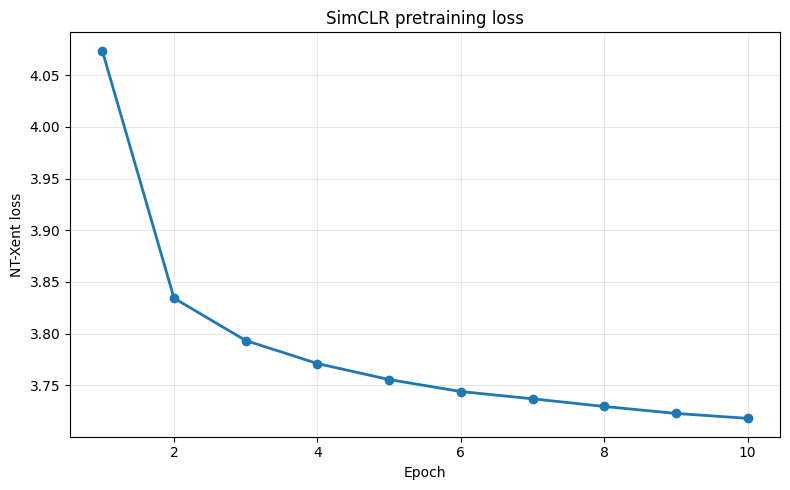

Saved: /Users/sherry/Desktop/Tomato_Disease/RESULTS/simclr/simclr_checkpoint.pth


In [10]:
SIMCLR_CKPT = f"{RESULTS_DIR}/simclr/simclr_checkpoint.pth"

if os.path.exists(SIMCLR_CKPT):
    print(f"SimCLR checkpoint already exists at:\n  {SIMCLR_CKPT}")
    print("Skipping pretraining (delete the file to force a retrain).")
    simclr_ckpt = torch.load(SIMCLR_CKPT, map_location=device, weights_only=False)
    print(f"Loaded checkpoint (final loss = {simclr_ckpt['final_loss']:.4f}).")
else:
    set_seed(SEED)
    ssl_dataset = SimCLRDataset(TOMATO_PATH, simclr_transform)
    ssl_loader  = DataLoader(ssl_dataset, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    print(f"SSL dataset: {len(ssl_dataset)} images, {len(ssl_loader)} batches/epoch")

    simclr_model = SimCLRModel(feature_dim=128, init="imagenet").to(device)
    simclr_optimizer = torch.optim.Adam(simclr_model.parameters(), lr=LR_SIMCLR)

    print("=" * 64)
    print(f"SimCLR fine-tune from ImageNet: {SIMCLR_EPOCHS} epochs")
    print(f"Batch: {BATCH_SIZE}  LR: {LR_SIMCLR}  Temp: {SIMCLR_TEMP}")
    print("=" * 64)

    simclr_ft_history = {"epoch": [], "loss": [], "time_min": []}
    overall_start = time.time()

    for epoch in range(SIMCLR_EPOCHS):
        simclr_model.train()
        epoch_start = time.time()
        total_loss, n_batches = 0.0, 0
        pbar = tqdm(ssl_loader, desc=f"SimCLR {epoch+1}/{SIMCLR_EPOCHS}")
        for xi, xj in pbar:
            xi = xi.to(device, non_blocking=True)
            xj = xj.to(device, non_blocking=True)
            _, zi = simclr_model(xi)
            _, zj = simclr_model(xj)
            loss = nt_xent_loss(zi, zj, temperature=SIMCLR_TEMP)
            simclr_optimizer.zero_grad(); loss.backward(); simclr_optimizer.step()
            total_loss += loss.item(); n_batches += 1
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_loss = total_loss / n_batches
        epoch_min = (time.time() - epoch_start) / 60
        simclr_ft_history["epoch"].append(epoch + 1)
        simclr_ft_history["loss"].append(avg_loss)
        simclr_ft_history["time_min"].append(epoch_min)
        print(f"  Epoch {epoch+1}/{SIMCLR_EPOCHS}  loss={avg_loss:.4f}  time={epoch_min:.1f}min")

    total_min = (time.time() - overall_start) / 60
    print(f"\nSimCLR pretraining complete. Total time: {total_min:.1f} min")

    # Save checkpoint
    torch.save({
        "model_state_dict": simclr_model.state_dict(),
        "encoder_state_dict": simclr_model.encoder.state_dict(),
        "projector_state_dict": simclr_model.projector.state_dict(),
        "epoch": SIMCLR_EPOCHS,
        "final_loss": simclr_ft_history["loss"][-1],
        "config": {"init": "imagenet", "epochs": SIMCLR_EPOCHS,
                   "batch_size": BATCH_SIZE, "lr": LR_SIMCLR,
                   "temperature": SIMCLR_TEMP, "feature_dim": 128},
    }, SIMCLR_CKPT)
    with open(f"{RESULTS_DIR}/simclr/simclr_history.json", "w") as f:
        json.dump(simclr_ft_history, f, indent=2)

    # Loss curve
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(simclr_ft_history["epoch"], simclr_ft_history["loss"],
            marker="o", linewidth=2)
    ax.set_xlabel("Epoch"); ax.set_ylabel("NT-Xent loss")
    ax.set_title("SimCLR pretraining loss")
    ax.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/simclr/simclr_loss_curve.png", dpi=150)
    plt.show()

    simclr_ckpt = torch.load(SIMCLR_CKPT, map_location=device, weights_only=False)
    del simclr_model, simclr_optimizer
    empty_cache()
    print(f"Saved: {SIMCLR_CKPT}")

## Section 9 — Configure current label % and build loaders

**This is the cell you re-run for each experiment.** Set `LABEL_PCT` to one of
`0.01`, `0.20`, `0.40`, then run this cell **and** sections 10–13. Section 14
collates everything at the end.

Splits are deterministic per seed, so the same images go to the same buckets every
time you run this with the same `LABEL_PCT`.

> **Important:** validation stays at 10% across all experiments — only the labeled /
> unlabeled split shifts.

In [22]:
# ============================================================
# CHANGE THIS to 0.01, 0.20, or 0.40 between experiments
# ============================================================
LABEL_PCT = 0.01
# ============================================================

pct_tag = f"{int(LABEL_PCT*100)}pct"
CUR_OUT = f"{RESULTS_DIR}/{pct_tag}"
print(f"Active experiment: LABEL_PCT={LABEL_PCT}  (tag: {pct_tag})")
print(f"Output base:       {CUR_OUT}")

# Build the split deterministically
set_seed(SEED)
labeled_idx, unlabeled_idx, val_idx = stratified_split_with_floor(
    base_dataset, label_pct=LABEL_PCT, val_pct=VAL_PCT,
    min_per_class=10, seed=SEED,
)

total_n = len(base_dataset)
print(f"\nSplit sizes (target label_pct={LABEL_PCT}, val_pct={VAL_PCT}, floor=10):")
print(f"  Labeled:    {len(labeled_idx):>5} ({100*len(labeled_idx)/total_n:.2f}%)")
print(f"  Unlabeled:  {len(unlabeled_idx):>5} ({100*len(unlabeled_idx)/total_n:.2f}%)")
print(f"  Validation: {len(val_idx):>5} ({100*len(val_idx)/total_n:.2f}%)")

# Save the split for reproducibility
with open(f"{RESULTS_DIR}/splits/split_{pct_tag}_seed{SEED}.json", "w") as f:
    json.dump({
        "seed": SEED, "label_pct": LABEL_PCT, "val_pct": VAL_PCT,
        "min_per_class": 10,
        "labeled_idx": labeled_idx,
        "unlabeled_idx": unlabeled_idx,
        "val_idx": val_idx,
        "classes": base_dataset.classes,
    }, f)

# Build datasets
labeled_dataset   = LabeledSubset(base_dataset, labeled_idx,   weak_transform)
unlabeled_dataset = UnlabeledKAug(base_dataset, unlabeled_idx, weak_transform, K=K_AUGMENTS)
val_dataset       = LabeledSubset(base_dataset, val_idx,       eval_transform)

# Loaders
labeled_loader = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=True)
# Plain (no drop_last) loader for supervised baselines so they see every labeled image
train_loader = DataLoader(labeled_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)

print(f"\nLoader batch counts:")
print(f"  labeled_loader:   {len(labeled_loader)}")
print(f"  unlabeled_loader: {len(unlabeled_loader)}")
print(f"  val_loader:       {len(val_loader)}")
print(f"  train_loader:     {len(train_loader)}")

# Collector for this percentage's results
results_cur = {}

Active experiment: LABEL_PCT=0.01  (tag: 1pct)
Output base:       /Users/sherry/Desktop/Tomato_Disease/RESULTS/1pct

Split sizes (target label_pct=0.01, val_pct=0.1, floor=10):
  Labeled:      164 (1.02%)
  Unlabeled:  14250 (89.00%)
  Validation:  1597 (9.97%)

Loader batch counts:
  labeled_loader:   1
  unlabeled_loader: 111
  val_loader:       13
  train_loader:     2


## Section 10 — B1: Supervised baseline (ImageNet init)

Plain ResNet-18 with ImageNet weights, classifier head re-initialised for our classes.
Trains only on the labeled split. This is the **floor** — any semi-/self-supervised
method should beat it.

In [23]:
# ===== B1: Supervised (ImageNet init) =====
set_seed(SEED)

sup_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
sup_model.fc = nn.Linear(512, NUM_CLASSES)
sup_model = sup_model.to(device)

LR_SUP = 1e-3
optimizer = torch.optim.Adam(sup_model.parameters(), lr=LR_SUP)
criterion = nn.CrossEntropyLoss()
EPOCHS = EPOCHS_DEFAULT

print("=" * 64)
print(f"B1 @ {pct_tag}: Supervised (ImageNet init)")
print(f"Epochs: {EPOCHS}  LR: {LR_SUP}  Batch: {BATCH_SIZE}")
print("=" * 64)

b1_history = {"epoch": [], "train_loss": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS):
    sup_model.train()
    tl, nb = 0.0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        loss = criterion(sup_model(imgs), labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tl += loss.item(); nb += 1

    sup_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (sup_model(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b1_history["epoch"].append(epoch + 1)
    b1_history["train_loss"].append(tl / nb)
    b1_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(sup_model.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS}  loss={tl/nb:.4f}  val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB1 done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

# Restore best weights for evaluation
sup_model.load_state_dict(best_state)
results_cur["B1_supervised"] = best

metrics_b1 = full_evaluation(
    model=sup_model, loader=val_loader,
    class_names=base_dataset.classes, method_name="B1_supervised",
    history=b1_history,
    out_dir=f"{CUR_OUT}/B1_supervised",
    pct_tag=pct_tag,
)

del sup_model, optimizer
empty_cache()

B1 @ 1pct: Supervised (ImageNet init)
Epochs: 30  LR: 0.001  Batch: 128


/Users/sherry/Desktop/Tomato_Disease/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Ep  1/30  loss=1.8136  val=57.04%  (best: 57.04%)
  Ep  2/30  loss=0.5826  val=60.80%  (best: 60.80%)
  Ep  3/30  loss=0.5074  val=51.22%  (best: 60.80%)
  Ep  4/30  loss=0.2863  val=49.41%  (best: 60.80%)
  Ep  5/30  loss=0.1861  val=53.29%  (best: 60.80%)
  Ep  6/30  loss=0.1093  val=59.80%  (best: 60.80%)
  Ep  7/30  loss=0.0913  val=68.07%  (best: 68.07%)
  Ep  8/30  loss=0.0307  val=67.56%  (best: 68.07%)
  Ep  9/30  loss=0.0455  val=66.31%  (best: 68.07%)
  Ep 10/30  loss=0.0485  val=62.12%  (best: 68.07%)
  Ep 11/30  loss=0.0483  val=66.62%  (best: 68.07%)
  Ep 12/30  loss=0.1716  val=68.75%  (best: 68.75%)
  Ep 13/30  loss=0.0371  val=70.88%  (best: 70.88%)
  Ep 14/30  loss=0.0869  val=69.63%  (best: 70.88%)
  Ep 15/30  loss=0.0382  val=66.25%  (best: 70.88%)
  Ep 16/30  loss=0.0130  val=58.55%  (best: 70.88%)
  Ep 17/30  loss=0.1122  val=65.06%  (best: 70.88%)
  Ep 18/30  loss=0.0249  val=67.94%  (best: 70.88%)
  Ep 19/30  loss=0.0731  val=69.19%  (best: 70.88%)
  Ep 20/30  

## Section 11 — B3: Self-supervised (SimCLR pretraining + full fine-tune)

Loads the SimCLR encoder from Section 8, attaches a fresh linear classifier, then
fine-tunes the **whole model** (not just the classifier) at a low LR (`1e-4`) to
preserve the learned representations. This is the standard SSL evaluation protocol.

In [24]:
# ===== B3: Self-supervised (SimCLR + Full Fine-tune) =====
class SimCLRFineTune(nn.Module):
    """SimCLR encoder + fresh linear classifier; both trainable."""
    def __init__(self, pretrained_encoder, num_classes):
        super().__init__()
        self.encoder = copy.deepcopy(pretrained_encoder)
        self.classifier = nn.Linear(512, num_classes)
    def forward(self, x):
        return self.classifier(self.encoder(x))


set_seed(SEED)
simclr_clean = SimCLRModel(feature_dim=128, init="imagenet").to(device)
simclr_clean.load_state_dict(simclr_ckpt["model_state_dict"])

ft_model = SimCLRFineTune(simclr_clean.encoder, NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(ft_model.parameters(), lr=1e-4)  # low LR to preserve SimCLR features
criterion = nn.CrossEntropyLoss()
EPOCHS = EPOCHS_DEFAULT

print("=" * 64)
print(f"B3 @ {pct_tag}: SimCLR + Full Fine-tune (LR=1e-4)")
print("=" * 64)

b3_history = {"epoch": [], "train_loss": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS):
    ft_model.train()
    tl, nb = 0.0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        loss = criterion(ft_model(imgs), labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tl += loss.item(); nb += 1

    ft_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (ft_model(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b3_history["epoch"].append(epoch + 1)
    b3_history["train_loss"].append(tl / nb)
    b3_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(ft_model.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS}  loss={tl/nb:.3f}  val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB3 done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

ft_model.load_state_dict(best_state)
results_cur["B3_self_supervised"] = best

metrics_b3 = full_evaluation(
    model=ft_model, loader=val_loader,
    class_names=base_dataset.classes, method_name="B3_self_supervised",
    history=b3_history,
    out_dir=f"{CUR_OUT}/B3_self_supervised",
    pct_tag=pct_tag,
)

del ft_model, optimizer, simclr_clean
empty_cache()

B3 @ 1pct: SimCLR + Full Fine-tune (LR=1e-4)


/Users/sherry/Desktop/Tomato_Disease/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Ep  1/30  loss=2.012  val=49.66%  (best: 49.66%)
  Ep  2/30  loss=1.552  val=63.56%  (best: 63.56%)
  Ep  3/30  loss=1.219  val=67.63%  (best: 67.63%)
  Ep  4/30  loss=1.033  val=69.57%  (best: 69.57%)
  Ep  5/30  loss=0.791  val=70.44%  (best: 70.44%)
  Ep  6/30  loss=0.724  val=72.32%  (best: 72.32%)
  Ep  7/30  loss=0.619  val=75.02%  (best: 75.02%)
  Ep  8/30  loss=0.515  val=77.21%  (best: 77.21%)
  Ep  9/30  loss=0.418  val=79.59%  (best: 79.59%)
  Ep 10/30  loss=0.320  val=80.03%  (best: 80.03%)
  Ep 11/30  loss=0.289  val=80.09%  (best: 80.09%)
  Ep 12/30  loss=0.239  val=81.09%  (best: 81.09%)
  Ep 13/30  loss=0.213  val=81.59%  (best: 81.59%)
  Ep 14/30  loss=0.157  val=82.91%  (best: 82.91%)
  Ep 15/30  loss=0.165  val=83.53%  (best: 83.53%)
  Ep 16/30  loss=0.128  val=83.78%  (best: 83.78%)
  Ep 17/30  loss=0.084  val=84.16%  (best: 84.16%)
  Ep 18/30  loss=0.084  val=84.85%  (best: 84.85%)
  Ep 19/30  loss=0.054  val=84.72%  (best: 84.85%)
  Ep 20/30  loss=0.052  val=85.

## Section 12 — B4: Semi-supervised (MixMatch, ImageNet init)

MixMatch's two-loss recipe:
- **Labeled side:** cross-entropy on MixUp'd labeled images
- **Unlabeled side:** MSE between predictions on MixUp'd unlabeled views and a *sharpened average* of K augmented predictions

Total loss = `lx + LAMBDA_U * lu`. ImageNet init only — no SimCLR here (that's B5).

In [25]:
# ===== B4: Semi-supervised MixMatch (ImageNet init) =====
set_seed(SEED)

mm_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
mm_model.fc = nn.Linear(512, NUM_CLASSES)
mm_model = mm_model.to(device)

LR_MM = 1e-4
optimizer = torch.optim.Adam(mm_model.parameters(), lr=LR_MM)
EPOCHS_MM = EPOCHS_DEFAULT

print("=" * 64)
print(f"B4 @ {pct_tag}: MixMatch (ImageNet init)")
print(f"Epochs: {EPOCHS_MM}  LR: {LR_MM}")
print("=" * 64)

b4_history = {"epoch": [], "loss_x": [], "loss_u": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS_MM):
    mm_model.train()
    tlx, tlu, nb = 0.0, 0.0, 0
    uiter = iter(unlabeled_loader)

    for bx, by in labeled_loader:
        try:
            buv = next(uiter)
        except StopIteration:
            uiter = iter(unlabeled_loader); buv = next(uiter)

        bx, by = bx.to(device), by.to(device)
        buv = [v.to(device) for v in buv]

        # Guess label: average K augmented views, then sharpen
        with torch.no_grad():
            probs = torch.zeros(buv[0].size(0), NUM_CLASSES, device=device)
            for v in buv:
                probs += F.softmax(mm_model(v), dim=1)
            probs /= len(buv)
            pseudo = sharpen(probs, T=SHARPEN_TEMP)

        # Concat labeled + K unlabeled views, MixUp everything
        loh = F.one_hot(by, num_classes=NUM_CLASSES).float()
        ai = torch.cat([bx] + buv, dim=0)
        at = torch.cat([loh] + [pseudo] * len(buv), dim=0)
        si = torch.randperm(ai.size(0))
        mx, my = mixup(ai, at, ai[si], at[si], alpha=MIXUP_ALPHA)

        n = bx.size(0)
        xp, yp = mx[:n], my[:n]
        up, uy = mx[n:], my[n:]

        lx = -torch.mean(torch.sum(yp * F.log_softmax(mm_model(xp), dim=1), dim=1))
        lu = F.mse_loss(F.softmax(mm_model(up), dim=1), uy)
        loss = lx + LAMBDA_U * lu

        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tlx += lx.item(); tlu += lu.item(); nb += 1

    mm_model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (mm_model(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b4_history["epoch"].append(epoch + 1)
    b4_history["loss_x"].append(tlx / nb)
    b4_history["loss_u"].append(tlu / nb)
    b4_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(mm_model.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS_MM}  lx={tlx/nb:.3f}  lu={tlu/nb:.4f}  "
          f"val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB4 done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

mm_model.load_state_dict(best_state)
results_cur["B4_semi_supervised"] = best

metrics_b4 = full_evaluation(
    model=mm_model, loader=val_loader,
    class_names=base_dataset.classes, method_name="B4_semi_supervised",
    history=b4_history,
    out_dir=f"{CUR_OUT}/B4_semi_supervised",
    pct_tag=pct_tag,
)

del mm_model, optimizer
empty_cache()

B4 @ 1pct: MixMatch (ImageNet init)
Epochs: 30  LR: 0.0001


/Users/sherry/Desktop/Tomato_Disease/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Ep  1/30  lx=2.308  lu=0.0108  val=21.48%  (best: 21.48%)
  Ep  2/30  lx=2.170  lu=0.0040  val=27.86%  (best: 27.86%)
  Ep  3/30  lx=1.817  lu=0.0048  val=38.82%  (best: 38.82%)
  Ep  4/30  lx=1.675  lu=0.0046  val=51.85%  (best: 51.85%)
  Ep  5/30  lx=1.968  lu=0.0102  val=60.99%  (best: 60.99%)
  Ep  6/30  lx=1.731  lu=0.0081  val=68.07%  (best: 68.07%)
  Ep  7/30  lx=1.696  lu=0.0094  val=71.57%  (best: 71.57%)
  Ep  8/30  lx=1.124  lu=0.0055  val=73.64%  (best: 73.64%)
  Ep  9/30  lx=1.668  lu=0.0114  val=74.08%  (best: 74.08%)
  Ep 10/30  lx=1.251  lu=0.0069  val=75.27%  (best: 75.27%)
  Ep 11/30  lx=0.641  lu=0.0065  val=75.89%  (best: 75.89%)
  Ep 12/30  lx=1.003  lu=0.0061  val=76.83%  (best: 76.83%)
  Ep 13/30  lx=0.621  lu=0.0062  val=77.71%  (best: 77.71%)
  Ep 14/30  lx=1.044  lu=0.0055  val=78.46%  (best: 78.46%)
  Ep 15/30  lx=1.297  lu=0.0114  val=79.21%  (best: 79.21%)
  Ep 16/30  lx=0.799  lu=0.0054  val=80.21%  (best: 80.21%)
  Ep 17/30  lx=0.325  lu=0.0067  val=81.

## Section 13 — B5 (full): Hybrid (SimCLR pretraining + MixMatch full fine-tune)

The full combo: start from SimCLR weights (Section 8), then run MixMatch (Section 12's
loss recipe) on top with the **whole encoder trainable**. This is what your original
notebook calls `B5_simclr_mixmatch_full`.

In [26]:
# ===== B5 (full): Hybrid — SimCLR + MixMatch full FT =====
class SimCLRMixMatchFull(nn.Module):
    """SimCLR encoder + fresh classifier, both trainable end-to-end."""
    def __init__(self, pretrained_encoder, num_classes):
        super().__init__()
        self.encoder = copy.deepcopy(pretrained_encoder)
        self.classifier = nn.Linear(512, num_classes)
    def forward(self, x):
        return self.classifier(self.encoder(x))


set_seed(SEED)
simclr_clean = SimCLRModel(feature_dim=128, init="imagenet").to(device)
simclr_clean.load_state_dict(simclr_ckpt["model_state_dict"])

b5_full = SimCLRMixMatchFull(simclr_clean.encoder, NUM_CLASSES).to(device)
# Sanity check — every param should be trainable
trainable = sum(p.numel() for p in b5_full.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in b5_full.parameters())
assert trainable == total_p, "Some params frozen — check copy.deepcopy / .eval() interaction"

optimizer = torch.optim.Adam(b5_full.parameters(), lr=1e-4)
EPOCHS = EPOCHS_DEFAULT

print("=" * 64)
print(f"B5 (full) @ {pct_tag}: SimCLR + MixMatch (full FT, LR=1e-4)")
print("=" * 64)

b5_history = {"epoch": [], "loss_x": [], "loss_u": [], "val_acc": []}
best, best_state = 0.0, None
start = time.time()

for epoch in range(EPOCHS):
    b5_full.train()
    tlx, tlu, nb = 0.0, 0.0, 0
    uiter = iter(unlabeled_loader)

    for bx, by in labeled_loader:
        try:
            buv = next(uiter)
        except StopIteration:
            uiter = iter(unlabeled_loader); buv = next(uiter)

        bx, by = bx.to(device), by.to(device)
        buv = [v.to(device) for v in buv]

        with torch.no_grad():
            probs = torch.zeros(buv[0].size(0), NUM_CLASSES, device=device)
            for v in buv:
                probs += F.softmax(b5_full(v), dim=1)
            probs /= len(buv)
            pseudo = sharpen(probs, T=SHARPEN_TEMP)

        loh = F.one_hot(by, num_classes=NUM_CLASSES).float()
        ai = torch.cat([bx] + buv, dim=0)
        at = torch.cat([loh] + [pseudo] * len(buv), dim=0)
        si = torch.randperm(ai.size(0))
        mx, my = mixup(ai, at, ai[si], at[si], alpha=MIXUP_ALPHA)

        n = bx.size(0)
        xp, yp = mx[:n], my[:n]
        up, uy = mx[n:], my[n:]

        lx = -torch.mean(torch.sum(yp * F.log_softmax(b5_full(xp), dim=1), dim=1))
        lu = F.mse_loss(F.softmax(b5_full(up), dim=1), uy)
        loss = lx + LAMBDA_U * lu

        optimizer.zero_grad(); loss.backward(); optimizer.step()
        tlx += lx.item(); tlu += lu.item(); nb += 1

    b5_full.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            correct += (b5_full(imgs).argmax(1) == labels).sum().item()
            total += labels.size(0)
    val_acc = 100 * correct / total

    b5_history["epoch"].append(epoch + 1)
    b5_history["loss_x"].append(tlx / nb)
    b5_history["loss_u"].append(tlu / nb)
    b5_history["val_acc"].append(val_acc)
    if val_acc > best:
        best = val_acc
        best_state = copy.deepcopy(b5_full.state_dict())
    print(f"  Ep {epoch+1:>2}/{EPOCHS}  lx={tlx/nb:.3f}  lu={tlu/nb:.4f}  "
          f"val={val_acc:.2f}%  (best: {best:.2f}%)")

print(f"\nB5 done. Time: {(time.time()-start)/60:.1f}m | Best: {best:.2f}%")

b5_full.load_state_dict(best_state)
results_cur["B5_hybrid"] = best

metrics_b5 = full_evaluation(
    model=b5_full, loader=val_loader,
    class_names=base_dataset.classes, method_name="B5_hybrid",
    history=b5_history,
    out_dir=f"{CUR_OUT}/B5_hybrid",
    pct_tag=pct_tag,
)

del b5_full, optimizer, simclr_clean
empty_cache()

# Snapshot for this label %
print("\n" + "=" * 64)
print(f"Results @ {pct_tag} (best val accuracy):")
print("=" * 64)
for method, acc in sorted(results_cur.items(), key=lambda kv: -kv[1]):
    print(f"  {method:<25} {acc:>6.2f}%")
with open(f"{CUR_OUT}/results_summary.json", "w") as f:
    json.dump(results_cur, f, indent=2)

B5 (full) @ 1pct: SimCLR + MixMatch (full FT, LR=1e-4)


/Users/sherry/Desktop/Tomato_Disease/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Ep  1/30  lx=2.163  lu=0.0120  val=38.95%  (best: 38.95%)
  Ep  2/30  lx=1.925  lu=0.0050  val=48.28%  (best: 48.28%)
  Ep  3/30  lx=1.640  lu=0.0057  val=58.86%  (best: 58.86%)
  Ep  4/30  lx=1.543  lu=0.0052  val=65.50%  (best: 65.50%)
  Ep  5/30  lx=1.812  lu=0.0124  val=68.13%  (best: 68.13%)
  Ep  6/30  lx=1.676  lu=0.0083  val=70.26%  (best: 70.26%)
  Ep  7/30  lx=1.647  lu=0.0098  val=72.07%  (best: 72.07%)
  Ep  8/30  lx=1.211  lu=0.0047  val=73.76%  (best: 73.76%)
  Ep  9/30  lx=1.628  lu=0.0120  val=74.33%  (best: 74.33%)
  Ep 10/30  lx=1.280  lu=0.0055  val=75.39%  (best: 75.39%)
  Ep 11/30  lx=0.803  lu=0.0064  val=76.21%  (best: 76.21%)
  Ep 12/30  lx=1.064  lu=0.0051  val=76.27%  (best: 76.27%)
  Ep 13/30  lx=0.709  lu=0.0060  val=77.33%  (best: 77.33%)
  Ep 14/30  lx=1.087  lu=0.0048  val=77.46%  (best: 77.46%)
  Ep 15/30  lx=1.465  lu=0.0109  val=77.90%  (best: 77.90%)
  Ep 16/30  lx=0.925  lu=0.0041  val=78.52%  (best: 78.52%)
  Ep 17/30  lx=0.493  lu=0.0053  val=79.

## Section 14 — Summary across all percentages

Run this after you've completed sections 9–13 for all three percentages (1%, 20%, 40%).
It walks `RESULTS/` and produces a comparison table + a grouped bar chart showing each
method's accuracy at every label %.

Label %  Method                      Acc   P(mac)   R(mac)  F1(mac)
----------------------------------------------------------------------
1pct     B1_supervised            75.02%   73.29%   72.81%   70.46%
1pct     B3_self_supervised       85.41%   81.17%   82.19%   81.22%
1pct     B4_semi_supervised       85.28%   83.19%   81.72%   81.66%
1pct     B5_hybrid                82.97%   77.89%   79.23%   77.97%
20pct    B1_supervised            97.24%   97.05%   97.06%   96.96%
20pct    B3_self_supervised       99.19%   98.83%   99.23%   99.02%
20pct    B4_semi_supervised       99.31%   99.00%   99.26%   99.13%
20pct    B5_hybrid                99.50%   99.52%   99.45%   99.48%
40pct    B1_supervised            98.56%   98.59%   98.24%   98.37%
40pct    B3_self_supervised       99.37%   99.37%   99.30%   99.33%
40pct    B4_semi_supervised       99.56%   99.56%   99.47%   99.51%
40pct    B5_hybrid                99.56%   99.60%   99.51%   99.55%


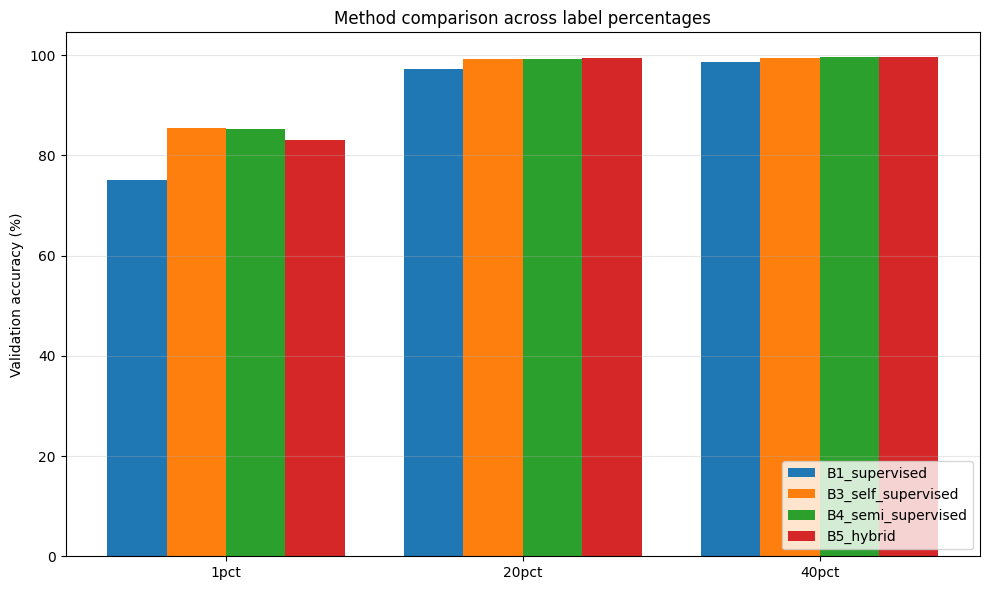


Summary saved to: /Users/sherry/Desktop/Tomato_Disease/RESULTS/summary/


In [27]:
import glob

rows = []
for pct in ["1pct", "20pct", "40pct"]:
    for method in ["B1_supervised", "B3_self_supervised",
                   "B4_semi_supervised", "B5_hybrid"]:
        p = f"{RESULTS_DIR}/{pct}/{method}/metrics.json"
        if not os.path.exists(p):
            continue
        with open(p) as f:
            m = json.load(f)
        rows.append({
            "pct": pct,
            "method": method,
            "accuracy":         m["overall"]["accuracy"],
            "precision_macro":  m["overall"]["precision_macro"],
            "recall_macro":     m["overall"]["recall_macro"],
            "f1_macro":         m["overall"]["f1_macro"],
        })

if not rows:
    print("No metrics found yet — run sections 9–13 for at least one LABEL_PCT first.")
else:
    # Print table
    print(f"{'Label %':<8} {'Method':<22} {'Acc':>8} {'P(mac)':>8} {'R(mac)':>8} {'F1(mac)':>8}")
    print("-" * 70)
    for r in rows:
        print(f"{r['pct']:<8} {r['method']:<22} "
              f"{r['accuracy']*100:>7.2f}% "
              f"{r['precision_macro']*100:>7.2f}% "
              f"{r['recall_macro']*100:>7.2f}% "
              f"{r['f1_macro']*100:>7.2f}%")

    # Save consolidated JSON
    with open(f"{RESULTS_DIR}/summary/all_results.json", "w") as f:
        json.dump(rows, f, indent=2)

    # Grouped bar chart
    methods = ["B1_supervised", "B3_self_supervised",
               "B4_semi_supervised", "B5_hybrid"]
    pcts    = ["1pct", "20pct", "40pct"]
    grid    = {(r["pct"], r["method"]): r["accuracy"] * 100 for r in rows}

    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(pcts))
    w = 0.2
    for i, m in enumerate(methods):
        vals = [grid.get((p, m), np.nan) for p in pcts]
        ax.bar(x + (i - 1.5) * w, vals, w, label=m)
    ax.set_xticks(x); ax.set_xticklabels(pcts)
    ax.set_ylabel("Validation accuracy (%)")
    ax.set_title("Method comparison across label percentages")
    ax.legend(loc="lower right"); ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/summary/comparison_chart.png", dpi=150)
    plt.show()

    print(f"\nSummary saved to: {RESULTS_DIR}/summary/")